In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp
from jax import vmap, random

from myutils import Ntime, ACFs, simulate_data_full_jit, set_detectors, load_tables, cov_resp


from scipy.linalg import toeplitz
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data 

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/skyRing/examples/simulations_220_221/../../src/myutils.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set up injection with known source parameters. This example uses O4 PSD, calculated around GW250114.
Similar mass as GW250114, with 221+220 modes in the ringdown signal.

In [3]:
# Injection parameters

# extras for simulation
factor     = 10
N          = 1
seed       = 31567 
T          = 0.1 + 0.2
srate      = 4096 
t0         = 0.0
fmin       = 30
fmax       = 1500
components = 70

# Main source parameters

M_obs      = 72 
chi_obs    = 0.75 
A220_obs   = 0.5
P220_obs   = 2.2 
A221_obs   = 0.8 
P221_obs   = 4.5 
ra         = 2.33
dec        = 0.19
psi        = 1.329
iota       = 0.65 


tgps       = 1420878141.2379541 


psdH_path  = "../../data/PSDs/PSD_H1_GW250114.txt"
psdL_path  = "../../data/PSDs/PSD_L1_GW250114.txt"
qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l2/n2l2m2.dat"


Calculate the H1 and L1 start times for the known injection GPS time ($t_{gps}$) and sky location.

In [4]:
delays = {}
tgps_calc = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_calc)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_calc = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_calc)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo

print('H1 start time : ', tH1)
print('L1 start time : ', tL1)

H1 start time :  1420878141.221026
L1 start time :  1420878141.2185555


H1 start time > L1 start time. So H1 time will be used as the common reference time during FULL-SKY analysis

In [6]:
## Simulation extras
dt_np = 1.0 / srate
Nt     = Ntime(srate=srate, T=T)
freqs_np = onp.fft.rfftfreq(Nt, d=dt_np)

fmin_eff = freqs_np[0]  if (fmin is None) else float(fmin)
fmax_eff = freqs_np[-1] if (fmax is None) else float(fmax)

i0 = int(onp.searchsorted(freqs_np, fmin_eff, side="left"))
i1 = int(onp.searchsorted(freqs_np, fmax_eff, side="right"))

freqs = jnp.asarray(freqs_np, dtype=jnp.float64)

psdH, psdL, omega_r, omega_i, omega_OT_r, omega_OT_i = load_tables(psdH_path, psdL_path, qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

L_H, L_L, resp_H, resp_L = cov_resp(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
set_detectors(resp_H, resp_L)

In [7]:
seed = int(seed) if seed is not None else  (time.time_ns() ^ int.from_bytes(os.urandom(4), "little")) & 0xFFFFFFFF
master = random.PRNGKey(int(seed)) 
row_keys = random.split(master, int(N)+1)

theta_GT = onp.array([M_obs, chi_obs, A220_obs, P220_obs, A221_obs, P221_obs, onp.cos(iota), ra, onp.cos(dec), psi], dtype=onp.float64) 

H_GT, _, h_H, h_L, h_H_t, h_L_t  = simulate_data_full_jit(
        params=theta_GT, 
        gmst=gmst, psdH=psdH, psdL=psdL, L_H=L_H, L_L=L_L,
        omega_r=omega_r, omega_i=omega_i, omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
        key=row_keys[-1], T=T, srate=srate, t0=t0, i0=i0, i1=i1, freqs=freqs, fmin=fmin, components=components, factor=factor
        )

In [9]:
dt = jnp.asarray(1.0/srate, dtype=jnp.float64)
Nlen = Ntime(srate=srate, T=T)
times  = jnp.arange(Nlen, dtype=jnp.float64) * dt

tH1_array = times + jnp.float64(tH1)
tL1_array = times + jnp.float64(tL1)

This is the full simulated ringdown signal. H1 and L1 peaks are according to the known sky locations.

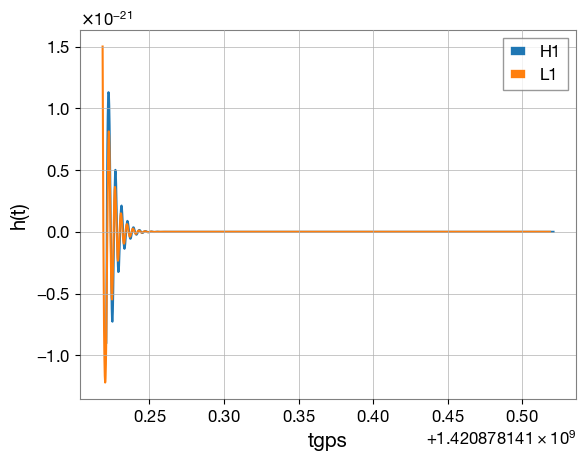

In [11]:
plt.plot(tH1_array, h_H_t, label='H1')
plt.plot(tL1_array, h_L_t, label='L1')
plt.xlabel('t_GPS')
plt.ylabel('h(t)')
plt.xlabel('tgps')
plt.legend()
plt.show()

Setting up data strains for analysis. 

FIXED-SKY method analysis the signal as is, assuming the sky location fixed at injection.

FULL-SKY assumes a common reference time. Since H1 start time > L1 start time, H1 time is chosen as the common start time and
L1 data is also truncated starting from H1 start time

In [12]:
analysis_T = 0.1
n_analyze  = Ntime(srate=srate, T=analysis_T)

H1idx_start = onp.argwhere(tH1_array>=tH1)[0][0]
L1idx_start = onp.argwhere(tL1_array>=tH1)[0][0]

H1_analysis_data_new = analysis_data(h_H_t, tH1_array, tH1, n_analyze)
L1_analysis_data_new = analysis_data(h_L_t, tL1_array, tH1, n_analyze)

H1_analysis_data_old = analysis_data(h_H_t, tH1_array, tH1, n_analyze)
L1_analysis_data_old = analysis_data(h_L_t, tL1_array, tL1, n_analyze)

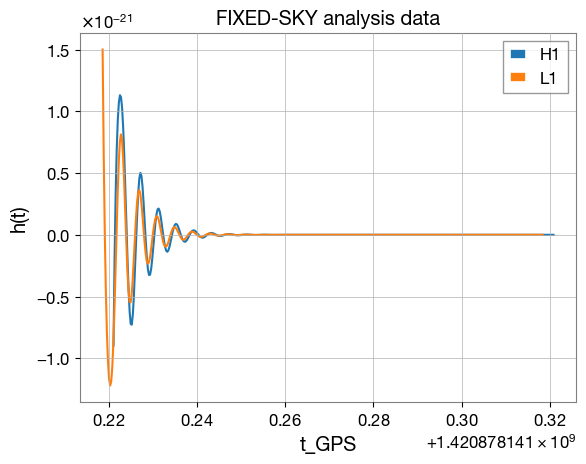

In [13]:
plt.plot(H1_analysis_data_old[0], H1_analysis_data_old[1], label='H1')
plt.plot(L1_analysis_data_old[0], L1_analysis_data_old[1], label='L1')
plt.xlabel('t_GPS')
plt.ylabel('h(t)')
plt.title('FIXED-SKY analysis data')
plt.legend()
plt.show()

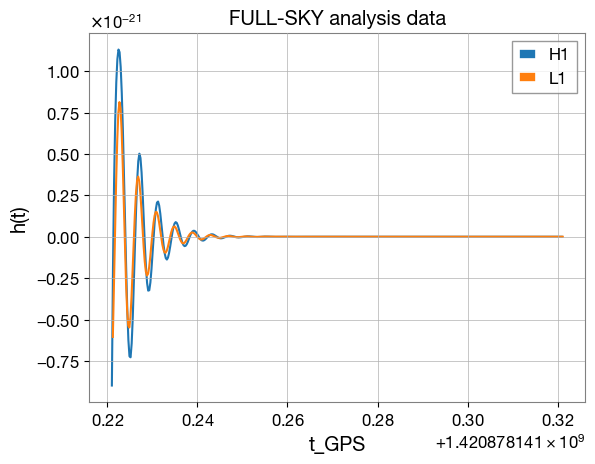

In [14]:
plt.plot(H1_analysis_data_new[0], H1_analysis_data_new[1], label='H1')
plt.plot(L1_analysis_data_new[0], L1_analysis_data_new[1], label='L1')
plt.xlabel('t_GPS')
plt.ylabel('h(t)')
plt.title('FULL-SKY analysis data')
plt.legend()
plt.show()

Save the data strains. 'new' and 'old' used as suffix for FULL-SKY and FIXED-SKY analysis data respectively

In [15]:
onp.savetxt('./H1-sim-new.txt', H1_analysis_data_new[1])
onp.savetxt('./L1-sim-new.txt', L1_analysis_data_new[1])

onp.savetxt('./H1-sim-old.txt', H1_analysis_data_old[1])
onp.savetxt('./L1-sim-old.txt', L1_analysis_data_old[1])

In [ ]:
# injection theta array


array([72.        ,  0.75      ,  0.5       ,  2.2       ,
        0.8       ,  4.5       ,  0.7960838 ,  2.33      ,
        0.98200424,  1.329     ])